In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

### Tradeoff Scatterplot

In [14]:
def visualize_tradeoff(IND_CSV, EXAG_CSV, model_name=None, ax=None, subplot_idx=0, total_subplots=1):
    ind_df = pd.read_csv(IND_CSV)
    exag_df = pd.read_csv(EXAG_CSV)

    merged_df = pd.merge(ind_df, exag_df, on=['intersectional_id', 'control_id'])
    merged_df[['Race', 'Gender', 'Occupation']] = merged_df['intersectional_id'].str.split('_', n=2, expand=True)

    avg_individuation = merged_df['f1_score'].mean()
    avg_exaggeration = merged_df['exaggeration'].mean()

    if ax is None:
        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(10, 7))

    # Define the "Goldilocks Zone" (High Individuation > 0.55, Low Exaggeration < 0.20)
    sweet_spot = Rectangle((0.55, 0.0), 0.45, 0.20, 
                            facecolor='green', alpha=0.1, zorder=0, label='Ideal User Simulations')
    ax.add_patch(sweet_spot)

    # Scatter plot, colored by Race to show no single group drives the caricature
    scatter = sns.scatterplot(
        data=merged_df,
        x='f1_score',
        y='exaggeration',
        hue='Race',
        palette='Set1',
        s=80,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        ax=ax,
        zorder=3
    )

    # Add Threshold Lines (only label on first subplot)
    ax.axhline(y=0.25, color='red', linestyle='--', linewidth=1.5, zorder=1)
    if subplot_idx == 0:
        ax.text(0.55, 0.255, 'Threshold of Caricature', color='red', fontsize=14, fontweight='bold')

    ax.axvline(x=0.50, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    if subplot_idx == 0:
        ax.text(0.505, 0.16, 'Random Chance', color='gray', fontsize=14, rotation=90, fontweight='bold')

    # Titles and Labels
    title = 'Exaggeration vs. Individuation'
    if model_name:
        title += f'\n({model_name})'
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Individuation (F1 Score)', fontsize=14)

    # Only show y-axis label on first subplot
    if subplot_idx == 0:
        ax.set_ylabel('Exaggeration Score', fontsize=14)
    else:
        ax.set_ylabel('')

    # Set limits to frame the data well
    ax.set_xlim(0.48, 0.90)
    ax.set_ylim(0.0, 0.30)

    # Legend only on last subplot
    handles, labels = ax.get_legend_handles_labels()
    if subplot_idx == total_subplots - 1:
        ax.legend(handles=handles, labels=labels, title='Race', fontsize=12, loc='upper left')
    else:
        ax.get_legend().remove()

    return avg_individuation, avg_exaggeration

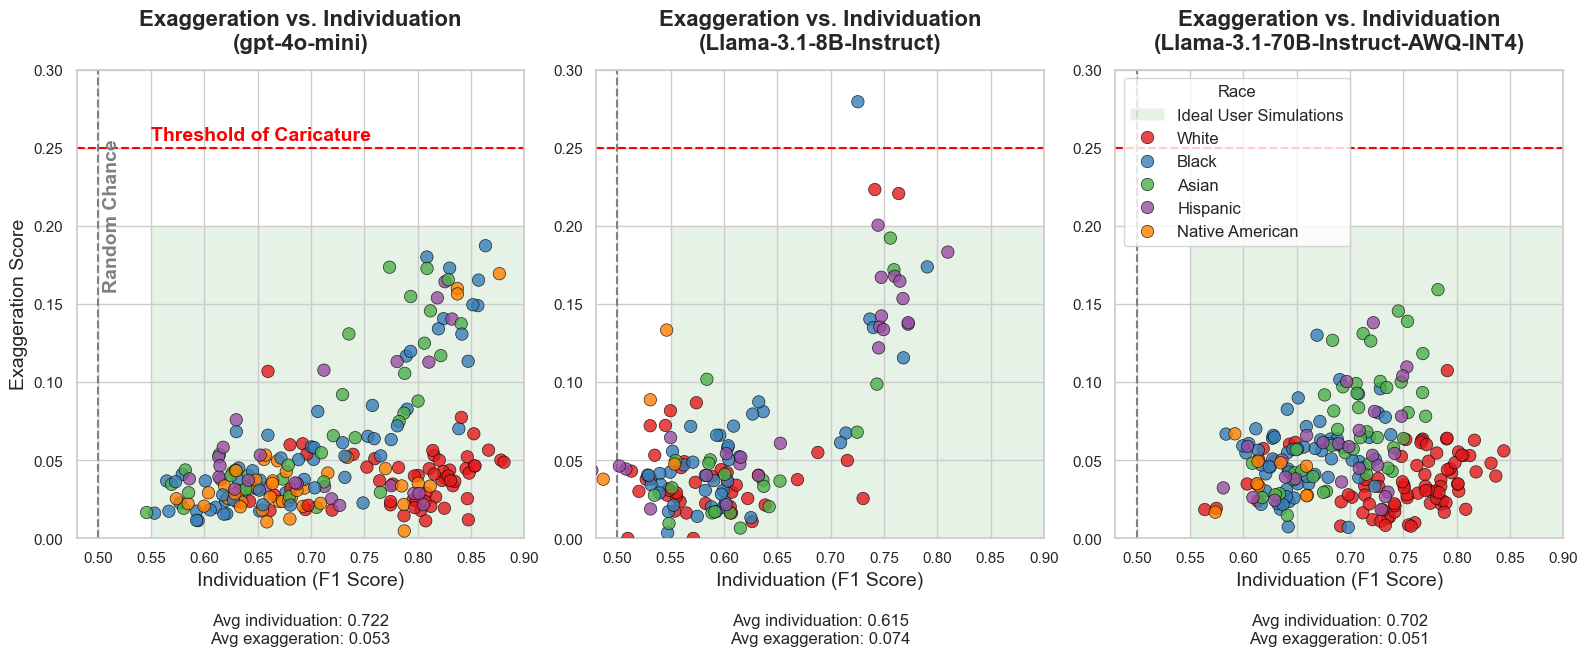

In [22]:
models = ["gpt-4o-mini", "Llama-3.1-8B-Instruct", "Llama-3.1-70B-Instruct-AWQ-INT4"]
baseline = "pairwise"
# baseline = "unmarked"

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

for idx, model in enumerate(models):
    IND_CSV = f"../{model}/{baseline}/individuation.csv"
    EXAG_CSV = f"../{model}/{baseline}/exaggeration.csv"
    avg_individuation, avg_exaggeration = visualize_tradeoff(
        IND_CSV,
        EXAG_CSV,
        model_name=model,
        ax=axes[idx],
        subplot_idx=idx,
        total_subplots=len(models)
    )
    axes[idx].text(
        0.5,
        -0.16,
        f"Avg individuation: {avg_individuation:.3f}\nAvg exaggeration: {avg_exaggeration:.3f}",
        transform=axes[idx].transAxes,
        ha='center',
        va='top',
        fontsize=12
    )

fig.subplots_adjust(bottom=0.28)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'CoMPosT-{baseline}.png', dpi=300, bbox_inches='tight')
plt.show()